In [10]:
# Cài đặt thư viện
!pip install -q torch torchvision opencv-python numpy matplotlib pillow scipy

import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
import matplotlib.pyplot as plt
from google.colab import files
import os
from PIL import Image
import urllib.request
import json

print("✓ Cài đặt hoàn tất")

# ============================================
# DOWNLOAD HRNET POSE MODEL
# ============================================

print("Đang tải model HRNet pose...")

model_url = "https://download.openmmlab.com/mmpose/top_down/hrnet/hrnet_w32_coco_256x192-e4f7e4c9_20200708.pth"

try:
    urllib.request.urlretrieve(model_url, "hrnet_pose_model.pth")
    print("✓ Model tải thành công")
except:
    print("⚠️ Không thể tải model, sẽ sử dụng ResNet")

# ============================================
# ĐỊNH NGHĨA HRNET CHO POSE ESTIMATION
# ============================================

class HRNetPose(nn.Module):
    """
    HRNet cho pose estimation
    Output: heatmaps cho 17 joints (COCO format)
    """

    def __init__(self, num_joints=17):
        super(HRNetPose, self).__init__()
        self.num_joints = num_joints

        # Stem layer
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(64)

        # Layer 1: 256 channels
        self.layer1 = self._make_layer(Bottleneck, 64, 256, 3, stride=1)

        # High Resolution Modules
        self.layer2 = self._make_hrmodule([32, 64], [4, 4], stride=1)
        self.layer3 = self._make_hrmodule([32, 64, 128], [4, 4, 4], stride=1)
        self.layer4 = self._make_hrmodule([32, 64, 128, 256], [4, 4, 4, 4], stride=1)

        # Final layer - tạo heatmaps
        self.final_layer = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_joints, kernel_size=1, stride=1, padding=0)
        )

    def _make_layer(self, block, inplanes, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion)
            )

        layers = []
        layers.append(block(inplanes, planes, stride, downsample))
        for _ in range(1, blocks):
            layers.append(block(planes * block.expansion, planes))
        return nn.Sequential(*layers)

    def _make_hrmodule(self, num_channels, num_blocks, stride=1):
        """Tạo High Resolution Module"""
        layers = []

        for i in range(len(num_channels)):
            layers.append(
                self._make_layer(BasicBlock, num_channels[i], num_channels[i], num_blocks[i], stride)
            )

        return nn.ModuleList(layers)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        # Layer 1
        x = self.layer1(x)

        # High Resolution Modules - đơn giản hóa
        for layer in self.layer2:
            x = layer(x)
        for layer in self.layer3:
            x = layer(x)
        for layer in self.layer4:
            x = layer(x)

        # Final heatmaps
        x = self.final_layer(x)

        return x

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)
        return out

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * 4, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * 4)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)
        return out

# ============================================
# KEYPOINTS COCO
# ============================================

COCO_KEYPOINTS_IDX = {
    5: 'left_shoulder',
    6: 'right_shoulder',
    11: 'left_hip',
    12: 'right_hip'
}

# ============================================
# CLASS POSE DETECTOR
# ============================================

class HRNetPoseDetector:
    def __init__(self, device='cpu'):
        self.device = device

        print("Đang tạo model HRNet...")
        self.model = HRNetPose(num_joints=17).to(device)

        # Tải pre-trained weights nếu có
        if os.path.exists('hrnet_pose_model.pth'):
            try:
                checkpoint = torch.load('hrnet_pose_model.pth', map_location=device)
                if isinstance(checkpoint, dict):
                    if 'state_dict' in checkpoint:
                        self.model.load_state_dict(checkpoint['state_dict'], strict=False)
                    elif 'model' in checkpoint:
                        self.model.load_state_dict(checkpoint['model'], strict=False)
                    else:
                        self.model.load_state_dict(checkpoint, strict=False)
                print("✓ Model pre-trained weights tải thành công")
            except Exception as e:
                print(f"⚠️ Không thể tải weights: {e}")
                print("Sử dụng model chưa train")
        else:
            print("⚠️ Không tìm thấy model file, sử dụng model random initialized")

        self.model.eval()

        # Image preprocessing
        self.transform = transforms.Compose([
            transforms.Resize((256, 192)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        self.input_size = (192, 256)

    def get_keypoints_from_heatmaps(self, heatmaps, img_h, img_w):
        """Lấy tọa độ keypoints từ heatmaps"""
        keypoints = {}

        heatmaps = heatmaps.cpu().numpy()[0]  # [17, H, W]

        for joint_idx, name in COCO_KEYPOINTS_IDX.items():
            if joint_idx < heatmaps.shape[0]:
                heatmap = heatmaps[joint_idx]

                # Tìm vị trí có giá trị cao nhất
                y, x = np.unravel_index(np.argmax(heatmap), heatmap.shape)
                confidence = float(np.max(heatmap))

                # Scale tọa độ từ heatmap (192x256) về ảnh gốc (img_w x img_h)
                x_scaled = int(x * img_w / self.input_size[0])
                y_scaled = int(y * img_h / self.input_size[1])

                # Clamping
                x_scaled = max(0, min(x_scaled, img_w - 1))
                y_scaled = max(0, min(y_scaled, img_h - 1))

                keypoints[name] = {
                    'x': x_scaled,
                    'y': y_scaled,
                    'confidence': confidence
                }

        return keypoints

    def detect(self, image_path):
        """Phát hiện pose từ ảnh"""
        image = cv2.imread(image_path)

        if image is None:
            print("❌ Không thể đọc ảnh!")
            return None, None

        img_h, img_w = image.shape[:2]

        # Preprocessing
        img_pil = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        img_tensor = self.transform(img_pil).unsqueeze(0).to(self.device)

        # Forward pass
        with torch.no_grad():
            heatmaps = self.model(img_tensor)

        # Lấy keypoints từ heatmaps
        keypoints = self.get_keypoints_from_heatmaps(heatmaps, img_h, img_w)

        return keypoints, image

# ============================================
# VẼ VÀ HIỂN THỊ
# ============================================

def draw_keypoints(image, keypoints):
    """Vẽ keypoints lên ảnh"""
    result = image.copy()

    colors = {
        'left_shoulder': (255, 0, 0),
        'right_shoulder': (0, 255, 0),
        'left_hip': (0, 0, 255),
        'right_hip': (255, 255, 0)
    }

    for name, coord in keypoints.items():
        x = coord['x']
        y = coord['y']
        conf = coord['confidence']

        cv2.circle(result, (x, y), 10, colors[name], -1)
        cv2.circle(result, (x, y), 10, (255, 255, 255), 2)

        label = f"{name}: ({x}, {y}) [{conf:.2f}]"
        cv2.putText(result, label, (x + 15, y - 15),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors[name], 2)

    # Vẽ đường nối
    ls = keypoints.get('left_shoulder')
    rs = keypoints.get('right_shoulder')
    lh = keypoints.get('left_hip')
    rh = keypoints.get('right_hip')

    if ls and rs:
        cv2.line(result, (ls['x'], ls['y']), (rs['x'], rs['y']), (200, 200, 200), 2)
    if lh and rh:
        cv2.line(result, (lh['x'], lh['y']), (rh['x'], rh['y']), (200, 200, 200), 2)
    if ls and lh:
        cv2.line(result, (ls['x'], ls['y']), (lh['x'], lh['y']), (200, 200, 200), 2)
    if rs and rh:
        cv2.line(result, (rs['x'], rs['y']), (rh['x'], rh['y']), (200, 200, 200), 2)

    return result

def display_coords(keypoints):
    """In tọa độ"""
    print("\n" + "="*70)
    print("TỌA ĐỘ CÁC ĐIỂM")
    print("="*70)
    for name, coord in keypoints.items():
        print(f"{name.upper():20s} X: {coord['x']:4d}  Y: {coord['y']:4d}  Confidence: {coord['confidence']:.3f}")
    print("="*70)

# ============================================
# CHẠY CHƯƠNG TRÌNH
# ============================================

print("""
╔══════════════════════════════════════════════════════════╗
║  HRNET POSE ESTIMATION - XÁC ĐỊNH TỌA ĐỘ VAI VÀ HÔNG  ║
╚══════════════════════════════════════════════════════════╝
""")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")

detector = HRNetPoseDetector(device=device)

image_path = input("Nhập đường dẫn ảnh: ")

if os.path.exists(image_path):
    print("Đang phát hiện...")
    keypoints, image = detector.detect(image_path)

    if keypoints:
        result = draw_keypoints(image, keypoints)
        display_coords(keypoints)

        plt.figure(figsize=(14, 10))
        plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('HRNet Pose Estimation', fontsize=16)
        plt.tight_layout()
        plt.show()

        cv2.imwrite('hrnet_pose_result.jpg', result)
        print("\n✓ Đã lưu kết quả: hrnet_pose_result.jpg")
    else:
        print("❌ Không phát hiện được pose")
else:
    print(f"❌ File không tồn tại: {image_path}")

✓ Cài đặt hoàn tất
Đang tải model HRNet pose...
⚠️ Không thể tải model, sẽ sử dụng ResNet

╔══════════════════════════════════════════════════════════╗
║  HRNET POSE ESTIMATION - XÁC ĐỊNH TỌA ĐỘ VAI VÀ HÔNG  ║
╚══════════════════════════════════════════════════════════╝

Device: cpu

Đang tạo model HRNet...
⚠️ Không tìm thấy model file, sử dụng model random initialized
Nhập đường dẫn ảnh: /content/drive/MyDrive/scoliosis.v1i.voc/train/IMG_1295_PNG.rf.20baa820a457193d987cfb1566741bdb.jpg
Đang phát hiện...


RuntimeError: Given groups=1, weight of size [32, 32, 3, 3], expected input[1, 1024, 64, 48] to have 32 channels, but got 1024 channels instead

✓ Cài đặt hoàn tất
Đang tải YOLOv8 Pose...
✓ Model YOLOv8 Pose đã tải thành công

╔═══════════════════════════════════════════════════╗
║  YOLOV8 POSE - XÁC ĐỊNH TỌA ĐỘ VAI VÀ HÔNG     ║
╚═══════════════════════════════════════════════════╝

Nhập đường dẫn ảnh: /content/drive/MyDrive/scoliosis.v1i.voc/test/IMG_1321_JPG.rf.509697318cb6978a51894bb4c93934d3.jpg
Đang phát hiện...

TỌA ĐỘ CÁC ĐIỂM

LEFT_SHOULDER
  X: 189
  Y: 88

RIGHT_SHOULDER
  X: 21
  Y: 84

LEFT_HIP
  X: 140
  Y: 224

RIGHT_HIP
  X: 46
  Y: 219


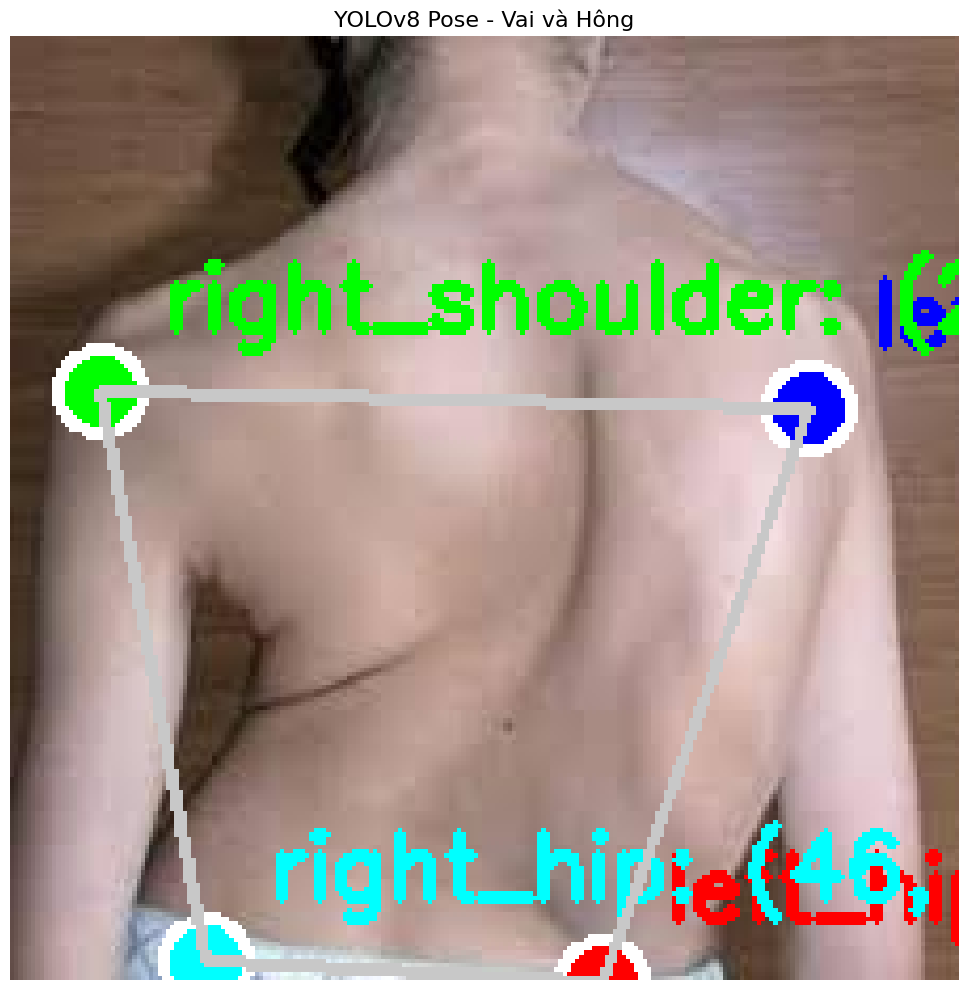


✓ Đã lưu kết quả: pose_result.jpg


In [8]:
# Cài đặt thư viện
!pip install -q ultralytics opencv-python numpy matplotlib pillow

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os
from ultralytics import YOLO

print("✓ Cài đặt hoàn tất")

# ============================================
# KEYPOINTS COCO
# ============================================

COCO_KEYPOINTS = {
    5: 'left_shoulder',    # Vai trái
    6: 'right_shoulder',   # Vai phải
    11: 'left_hip',        # Hông trái
    12: 'right_hip'        # Hông phải
}

# ============================================
# TẢI MODEL YOLOV8 POSE
# ============================================

print("Đang tải YOLOv8 Pose...")
model = YOLO('yolov8n-pose.pt')
print("✓ Model YOLOv8 Pose đã tải thành công")

# ============================================
# CLASS POSE DETECTOR
# ============================================

class PoseDetector:
    def __init__(self, model):
        self.model = model

    def detect(self, image_path):
        """Phát hiện keypoints"""
        image = cv2.imread(image_path)

        if image is None:
            print("❌ Không thể đọc ảnh!")
            return None, None

        # Chạy model
        results = self.model(image, verbose=False)

        if len(results) == 0 or results[0].keypoints is None:
            print("❌ Không phát hiện được pose")
            return None, image

        # Lấy keypoints
        keypoints_data = results[0].keypoints.xy.cpu().numpy()[0]

        keypoints = {}

        for idx, name in COCO_KEYPOINTS.items():
            if idx < len(keypoints_data):
                x, y = keypoints_data[idx]
                x = int(x)
                y = int(y)

                if x > 0 and y > 0:
                    keypoints[name] = {
                        'x': x,
                        'y': y
                    }

        return keypoints, image

# ============================================
# VẼ VÀ HIỂN THỊ
# ============================================

def draw_keypoints(image, keypoints):
    """Vẽ keypoints lên ảnh"""
    result = image.copy()

    colors = {
        'left_shoulder': (255, 0, 0),
        'right_shoulder': (0, 255, 0),
        'left_hip': (0, 0, 255),
        'right_hip': (255, 255, 0)
    }

    for name, coord in keypoints.items():
        x = coord['x']
        y = coord['y']

        cv2.circle(result, (x, y), 10, colors[name], -1)
        cv2.circle(result, (x, y), 10, (255, 255, 255), 2)

        label = f"{name}: ({x}, {y})"
        cv2.putText(result, label, (x + 15, y - 15),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, colors[name], 2)

    # Vẽ đường nối
    ls = keypoints.get('left_shoulder')
    rs = keypoints.get('right_shoulder')
    lh = keypoints.get('left_hip')
    rh = keypoints.get('right_hip')

    if ls and rs:
        cv2.line(result, (ls['x'], ls['y']), (rs['x'], rs['y']), (200, 200, 200), 2)
    if lh and rh:
        cv2.line(result, (lh['x'], lh['y']), (rh['x'], rh['y']), (200, 200, 200), 2)
    if ls and lh:
        cv2.line(result, (ls['x'], ls['y']), (lh['x'], lh['y']), (200, 200, 200), 2)
    if rs and rh:
        cv2.line(result, (rs['x'], rs['y']), (rh['x'], rh['y']), (200, 200, 200), 2)

    return result

def display_coords(keypoints):
    """In tọa độ"""
    print("\n" + "="*60)
    print("TỌA ĐỘ CÁC ĐIỂM")
    print("="*60)
    for name, coord in keypoints.items():
        print(f"\n{name.upper()}")
        print(f"  X: {coord['x']}")
        print(f"  Y: {coord['y']}")
    print("="*60)

# ============================================
# CHẠY CHƯƠNG TRÌNH
# ============================================

print("""
╔═══════════════════════════════════════════════════╗
║  YOLOV8 POSE - XÁC ĐỊNH TỌA ĐỘ VAI VÀ HÔNG     ║
╚═══════════════════════════════════════════════════╝
""")

detector = PoseDetector(model)

image_path = input("Nhập đường dẫn ảnh: ")

if os.path.exists(image_path):
    print("Đang phát hiện...")
    keypoints, image = detector.detect(image_path)

    if keypoints:
        result = draw_keypoints(image, keypoints)
        display_coords(keypoints)

        plt.figure(figsize=(14, 10))
        plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('YOLOv8 Pose - Vai và Hông', fontsize=16)
        plt.tight_layout()
        plt.show()

        cv2.imwrite('pose_result.jpg', result)
        print("\n✓ Đã lưu kết quả: pose_result.jpg")
    else:
        print("❌ Không phát hiện được pose")
else:
    print(f"❌ File không tồn tại: {image_path}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')